# Demo

A demostration script for the ECLYPSE network simulator extension.

It sets up a topology:

- Sensor → Gateway
- SensorX → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
from eclypse.placement.strategies import StaticStrategy
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from traffic_event import TrafficRoutingExecutionEvent
from eclypse.simulation import Simulation
from eclypse.utils.defaults import DEFAULT_EDGE_LATENCY

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor","SensorX", "SensorY", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node, processing_time = 0.0001)  # 0.1 ms processing time for all nodes

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)
# Access Link (SensorX -> Gateway): 200 Mbps, 1 km
infra.add_edge("SensorX", "Gateway", bandwidth_mbps=200, length_km=1)
# Access Link (SensorY -> R1): 200 Mbps, 1 km
infra.add_edge("SensorY", "R1", bandwidth_mbps=200, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("SensorX1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("SensorY1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)

app.add_edge("Sensor1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )


app.add_edge("SensorX1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

app.add_edge("SensorY1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

packet_event = PacketGenerationEvent()

execution_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
reporting_metric = TrafficRoutingMetric(step_duration_s=0.0005)

sim_config = SimulationConfig(
    seed=42,
    max_steps=11,
    step_every_ms=500,
    path="./results",
    events=[packet_event, execution_event, reporting_metric],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
    log_level="DEBUG"
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "SensorX1": "SensorX",
    "SensorY1": "SensorY",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
11:13:29.624 | INFO | VideoApp - Added flow Sensor1->Cloud1: ~10 pkt/step (avg), size 1500B
11:13:29.625 | INFO | VideoApp - Added flow SensorX1->Cloud1: ~10 pkt/step (avg), size 1500B
11:13:29.625 | INFO | VideoApp - Added flow SensorY1->Cloud1: ~10 pkt/step (avg), size 1500B


3. Initializing Simulation...
11:13:29.834 | DEBUG | Simulation - Registered application | app=VideoApp | remote=False
11:13:29.837 | DEBUG | Simulation - Event triggered | name=enact | triggers=1
11:13:29.836 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results | remote=False | step_every_ms=500 | max_steps=11 | seed=42 | report_format=json | report_backend=pandas | log_level=DEBUG | log_to_file=False | include_default_metrics=False
11:13:29.837 | DEBUG | Simulation - Event triggered | name=step | triggers=1
11:13:29.837 | DEBUG | Simulation - Event fired | name=start | calls=0
11:13:29.838 | ECLYPSE | Simulation - Simulation started.
11:13:29.837 | DEBUG | Simulation - Event fired | name=enact | calls=0
11:13:29.842 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'SensorX1': 'SensorX', 'SensorY1': 'SensorY', 'Cloud1': 'Cloud'}
11:13:29.842 | ECLYPSE | Simulation - Simulation step | step=1
11:

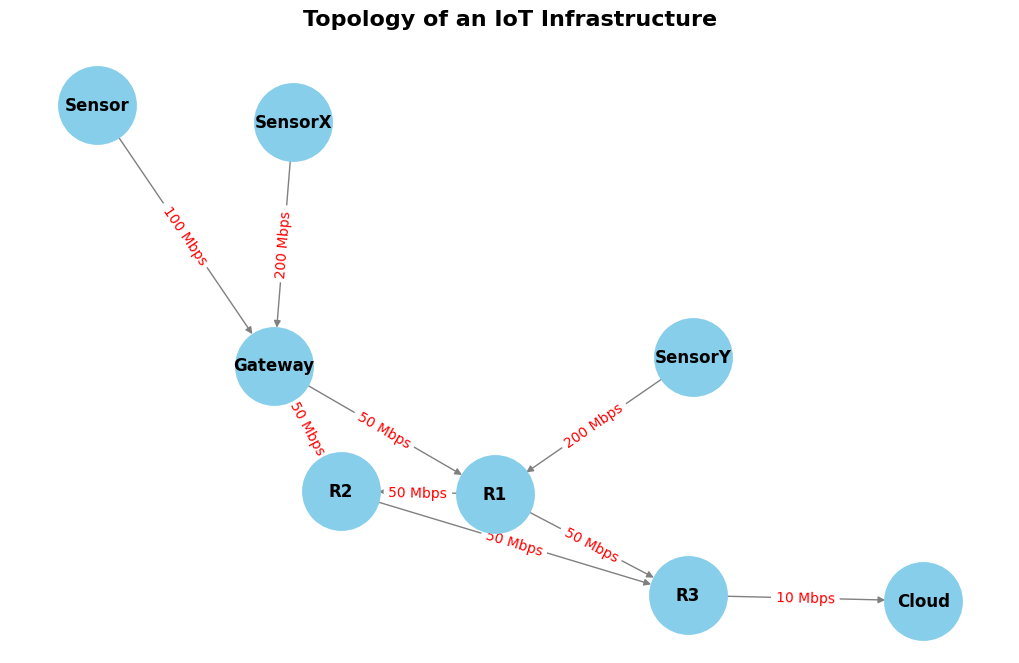

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from the infrastructure
plt.figure(figsize=(10, 6))

pos_base = nx.kamada_kawai_layout(infra)
pos = nx.spring_layout(infra, pos=pos_base, k=1.0, iterations=50, seed=42)
# Draw the network with custom styling
nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

# print the bandwidth on the edges using the 'bandwidth_mbps' attribute
edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    # add "Mbps" to the bandwidth values for better readability
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')  # Hide axes for better visualization
plt.show()

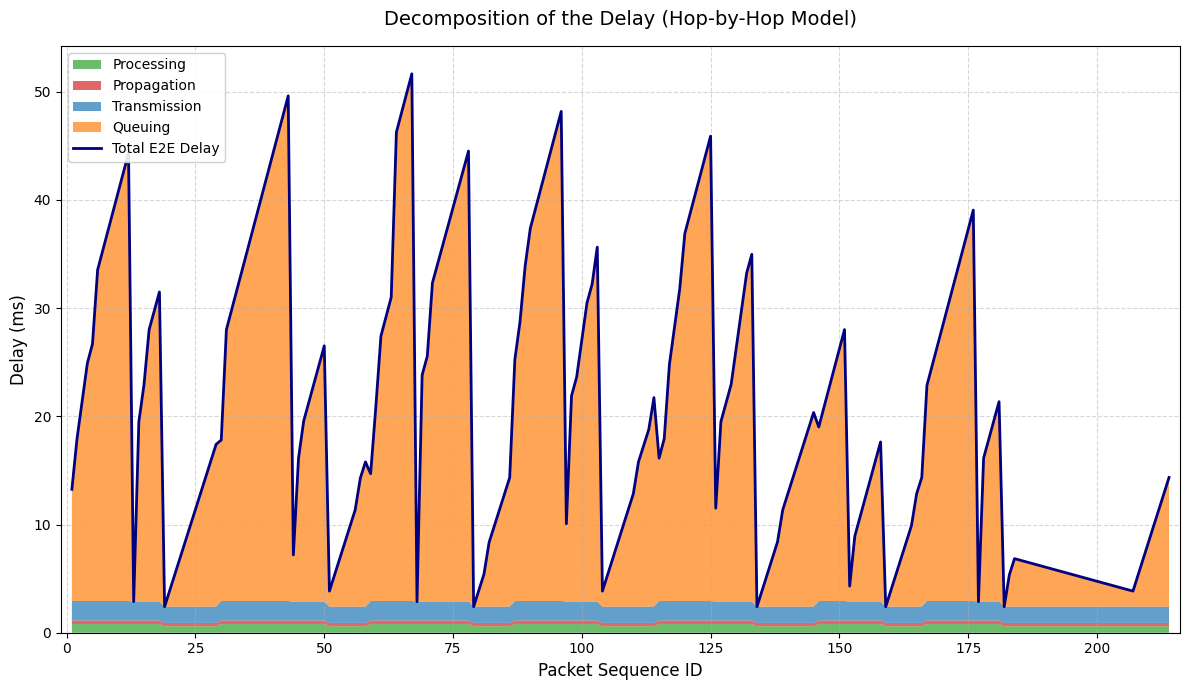


Decomposition of the last packet (ID 214):
- Processing:   0.6000 ms
- Propagation:  0.3050 ms
- Transmission: 1.5000 ms
- Queuing:      11.9400 ms
--------------------------------
= TOTAL E2E:    14.3450 ms


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Open the JSONL file and read the metrics
json_path = "./results/json/application.jsonl" # Sostituisci con la cartella corretta
records = []

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

df_raw = pd.DataFrame(records)

# Extraction of Packet ID and Field from the metric name
extracted = df_raw['metric'].str.extract(r'pkt_(\d+)_(.*)')
df_raw['Packet_ID'] = extracted[0].astype(float)
df_raw['Field'] = extracted[1]

# Clean the Data
df_raw = df_raw.dropna(subset=['Packet_ID'])
df_raw['Packet_ID'] = df_raw['Packet_ID'].astype(int)

# Create the pivot table to have one row per packet and columns for each field
df_pivot = df_raw.pivot_table(
    index='Packet_ID', columns='Field', values='val', aggfunc='first'
).reset_index()

# Convert the columns to numeric types for plotting
numeric_cols = ['Total_Delay_ms', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col])

# Chronologically sort the packets and drop those without Total_Delay_ms for plotting
df_plot = df_pivot.sort_values('Packet_ID').dropna(subset=['Total_Delay_ms'])


plt.figure(figsize=(12, 7))
plt.stackplot(
    df_plot['Packet_ID'],
    df_plot['processing_ms'],
    df_plot['propagation_ms'],
    df_plot['transmission_ms'],
    df_plot['queue_ms'],
    labels=['Processing', 'Propagation', 'Transmission', 'Queuing'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], alpha=0.7
)

df_plot['Total_Delay_ms'] = (
    df_plot['processing_ms'] +
    df_plot['propagation_ms'] +
    df_plot['transmission_ms'] +
    df_plot['queue_ms']
)

plt.plot(df_plot['Packet_ID'], df_plot['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')
plt.title("Decomposition of the Delay (Hop-by-Hop Model)", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.margins(x=0.01)
plt.tight_layout()
plt.show()

# Visualize the breakdown of the last packet's delay components
last_pkt = df_plot.iloc[-1]

print(f"\nDecomposition of the last packet (ID {int(last_pkt['Packet_ID'])}):")
print(f"- Processing:   {last_pkt['processing_ms']:.4f} ms")
print(f"- Propagation:  {last_pkt['propagation_ms']:.4f} ms")
print(f"- Transmission: {last_pkt['transmission_ms']:.4f} ms")
print(f"- Queuing:      {last_pkt['queue_ms']:.4f} ms")
print(f"--------------------------------")
print(f"= TOTAL E2E:    {last_pkt['Total_Delay_ms']:.4f} ms")

In [5]:
import pandas as pd
import json

# Load the JSONL file and extract metrics
json_path = "./results/json/application.jsonl"
records = []

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

df_raw = pd.DataFrame(records)

# Filter and extract the data for individual Hops
df_hops = df_raw[df_raw['metric'].str.contains("_Hop_")].copy()
extracted = df_hops['metric'].str.extract(r'pkt_(\d+)_Hop_(\d+)_(.*)')
df_hops['Packet_ID'] = extracted[0].astype(int)
df_hops['Hop_ID'] = extracted[1].astype(int)
df_hops['Field'] = extracted[2]

# Pivot the DataFrame to have one row per packet-hop and columns for each field
df_pivot = df_hops.pivot_table(
    index=['Packet_ID', 'Hop_ID'], columns='Field', values='val', aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col])

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")
# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next')

for _, row in df_log.iterrows():
    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {row['hop']:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms")


--- Chronological Log of Hops ---
[Arrival:  0.7650 ms] | Pkt: 19  (Hop 1) | Route: SensorY->R1     | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.7650 ms] | Pkt: 13  (Hop 1) | Route: SensorX->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.8250 ms] | Pkt: 1   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.8250 ms] | Pkt: 20  (Hop 1) | Route: SensorY->R1     | Queue:  2 pkt | Delay Queue: 0.0600 ms
[Arrival:  0.8250 ms] | Pkt: 14  (Hop 1) | Route: SensorX->Gateway | Queue:  2 pkt | Delay Queue: 0.0600 ms
[Arrival:  0.8850 ms] | Pkt: 15  (Hop 1) | Route: SensorX->Gateway | Queue:  3 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.8850 ms] | Pkt: 21  (Hop 1) | Route: SensorY->R1     | Queue:  3 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.9450 ms] | Pkt: 22  (Hop 1) | Route: SensorY->R1     | Queue:  4 pkt | Delay Queue: 0.1800 ms
[Arrival:  0.9450 ms] | Pkt: 2   (Hop 1) | Route: Sensor->Gateway | Queue:  2 pkt | Delay Queue: 0.1200 ms

# Failure recovery

In [6]:
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import random
random.seed(42)

In [7]:
from eclypse.placement.strategies import StaticStrategy
from traffic_event import TrafficRoutingExecutionEvent
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from fault_injection import FaultInjectionEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")
infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node, processing_time = 0.0001)  # 0.1 ms processing time for all nodes

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)
# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge(
    "Sensor1", "Cloud1", packet_size_bytes=1500, avg_packets_per_step=2, bandwidth=0, latency=1000
)

packet_event = PacketGenerationEvent()
traffic_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
traffic_metric = TrafficRoutingMetric(step_duration_s=0.0005)

sim_config = SimulationConfig(
    seed=42,
    max_steps=101,
    step_every_ms=500,
    path="./results-20260511_160749",
    events=[packet_event, traffic_event, traffic_metric, FaultInjectionEvent],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({"Sensor1": "Sensor", "Cloud1": "Cloud"})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
3. Initializing Simulation...
11:00:38.151 | INFO | VideoApp - Added flow Sensor1->Cloud1: ~2 pkt/step (avg), size 1500B
11:00:38.225 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results-20260511_160749 | remote=False | step_every_ms=500 | max_steps=101 | seed=42 | report_format=json | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
11:00:38.230 | INFO | IoT_Network - Sensor order: [1 (APP), 2 (APP)]
11:00:38.226 | ECLYPSE | Simulation - Simulation started.
11:00:38.229 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
11:00:38.229 | ECLYPSE | Simulation - Simulation step | step=1
11:00:38.732 | INFO | IoT_Network - Sensor order: [3 (APP), 4 (APP), 5 (APP), 6 (APP)]
11:00:38.730 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'

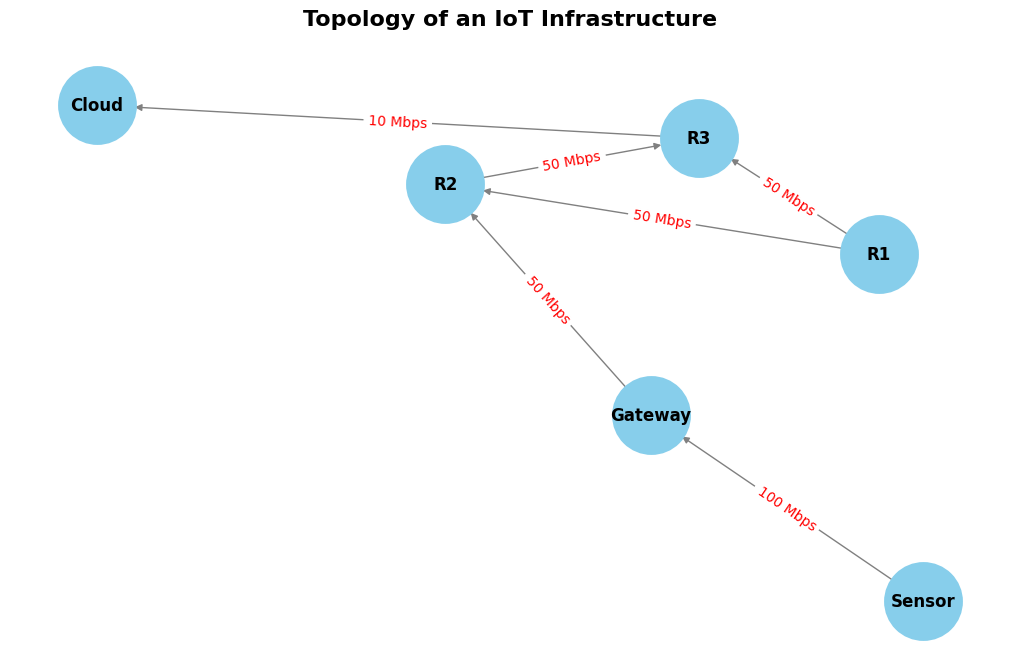

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(infra, seed=42)

nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

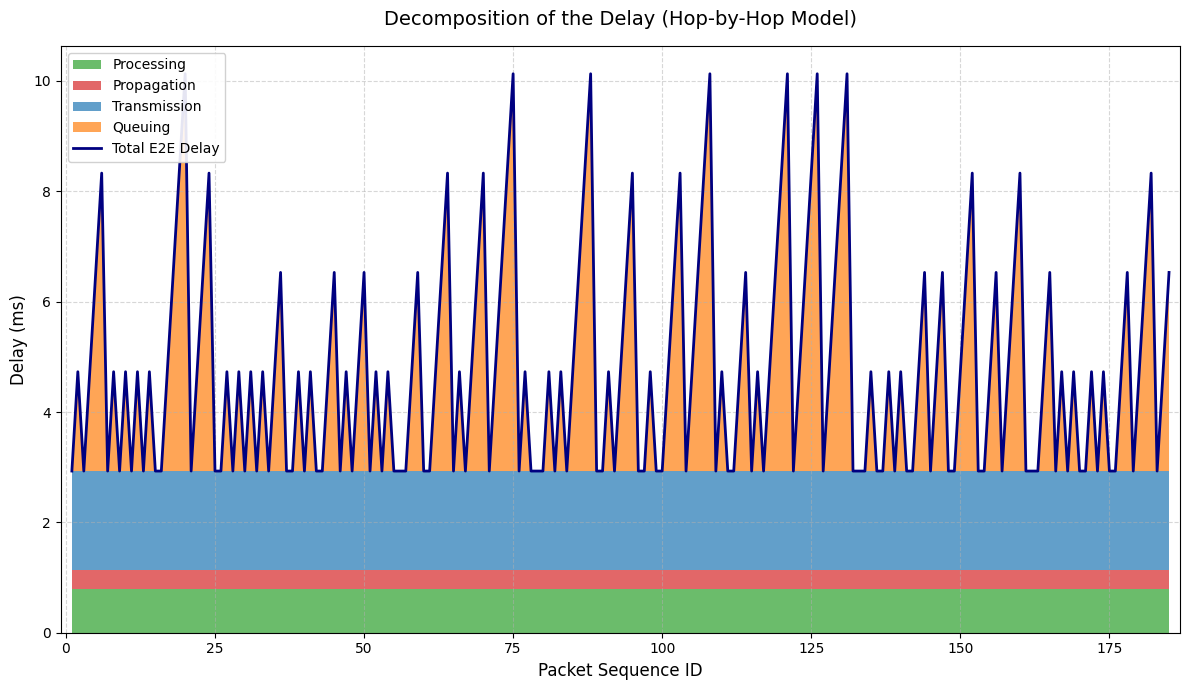


Decomposition of the last packet (ID 185):
- Processing:   0.8000 ms
- Propagation:  0.3300 ms
- Transmission: 1.8000 ms
- Queuing:      3.6000 ms
--------------------------------
= TOTAL E2E:    6.5300 ms


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import json
# Openining of the JSONL file and extracting the relevant metrics
json_path = "./results-20260511_160749/json/application.jsonl"
records = []

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

df_raw = pd.DataFrame(records)

# Extraction of Packet ID and Field from the metric name
extracted = df_raw['metric'].str.extract(r'pkt_(\d+)_(.*)')
df_raw['Packet_ID'] = extracted[0].astype(float)
df_raw['Field'] = extracted[1]

# Clean the Data
df_raw = df_raw.dropna(subset=['Packet_ID'])
df_raw['Packet_ID'] = df_raw['Packet_ID'].astype(int)

# Create the pivot table to have one row per packet and columns for each field
df_pivot = df_raw.pivot_table(
    index='Packet_ID', columns='Field', values='val', aggfunc='first'
).reset_index()

# Convert the columns to numeric types for plotting
numeric_cols = ['Total_Delay_ms', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col])

# Chronologically sort the packets and drop those without Total_Delay_ms for plotting
df_plot = df_pivot.sort_values('Packet_ID').dropna(subset=['Total_Delay_ms'])


plt.figure(figsize=(12, 7))
plt.stackplot(
    df_plot['Packet_ID'],
    df_plot['processing_ms'],
    df_plot['propagation_ms'],
    df_plot['transmission_ms'],
    df_plot['queue_ms'],
    labels=['Processing', 'Propagation', 'Transmission', 'Queuing'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], alpha=0.7
)

df_plot['Total_Delay_ms'] = (
    df_plot['processing_ms'] +
    df_plot['propagation_ms'] +
    df_plot['transmission_ms'] +
    df_plot['queue_ms']
)

plt.plot(df_plot['Packet_ID'], df_plot['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')
plt.title("Decomposition of the Delay (Hop-by-Hop Model)", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.margins(x=0.01)
plt.tight_layout()
plt.show()

# Visualize the breakdown of the last packet's delay components
last_pkt = df_plot.iloc[-1]

print(f"\nDecomposition of the last packet (ID {int(last_pkt['Packet_ID'])}):")
print(f"- Processing:   {last_pkt['processing_ms']:.4f} ms")
print(f"- Propagation:  {last_pkt['propagation_ms']:.4f} ms")
print(f"- Transmission: {last_pkt['transmission_ms']:.4f} ms")
print(f"- Queuing:      {last_pkt['queue_ms']:.4f} ms")
print(f"--------------------------------")
print(f"= TOTAL E2E:    {last_pkt['Total_Delay_ms']:.4f} ms")

In [10]:
import pandas as pd
import json

# Load the JSONL file and extract metrics
json_path = "./results-20260511_160749/json/application.jsonl"
records = []

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

df_raw = pd.DataFrame(records)

# Filter and extract the data for individual Hops
df_hops = df_raw[df_raw['metric'].str.contains("_Hop_")].copy()
extracted = df_hops['metric'].str.extract(r'pkt_(\d+)_Hop_(\d+)_(.*)')
df_hops['Packet_ID'] = extracted[0].astype(int)
df_hops['Hop_ID'] = extracted[1].astype(int)
df_hops['Field'] = extracted[2]

# Pivot the DataFrame to have one row per packet-hop and columns for each field
df_pivot = df_hops.pivot_table(
    index=['Packet_ID', 'Hop_ID'], columns='Field', values='val', aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col])

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")
# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next')

for _, row in df_log.iterrows():
    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {row['hop']:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms")


--- Chronological Log of Hops ---
[Arrival:  0.8250 ms] | Pkt: 1   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.9450 ms] | Pkt: 2   (Hop 1) | Route: Sensor->Gateway | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  1.3250 ms] | Pkt: 3   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  1.4450 ms] | Pkt: 4   (Hop 1) | Route: Sensor->Gateway | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  1.4650 ms] | Pkt: 1   (Hop 2) | Route: Gateway->R1     | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  1.5650 ms] | Pkt: 5   (Hop 1) | Route: Sensor->Gateway | Queue:  3 pkt | Delay Queue: 0.2400 ms
[Arrival:  1.6850 ms] | Pkt: 6   (Hop 1) | Route: Sensor->Gateway | Queue:  4 pkt | Delay Queue: 0.3600 ms
[Arrival:  1.7050 ms] | Pkt: 2   (Hop 2) | Route: Gateway->R1     | Queue:  2 pkt | Delay Queue: 0.2400 ms
[Arrival:  1.8250 ms] | Pkt: 7   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.0000 ms
[A